**Classification Hands-on (Training + Evaluation Demo)**

Dataset: Pima Indians Diabetes (diabetes.csv)

Goal: Keep it simple and focus on:
1) Training Logistic Regression
2) Evaluating with metrics + ROC AUC

**1. Setup**

In [1]:
# installing the dependencies
%pip install numpy pandas matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

**2. Load Data**

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**⚕️ Pima Indians Diabetes Dataset**

| Column Name | Description |
|------------|-------------|
| Pregnancies | Number of times the patient has been pregnant |
| Glucose | Plasma glucose concentration after 2 hours in an oral glucose tolerance test |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Thickness of the triceps skin fold (mm) |
| Insulin | 2 hour serum insulin level (mu U/ml) |
| BMI | Body Mass Index (weight in kg / height in m²) |
| DiabetesPedigreeFunction | Likelihood of diabetes based on family history |
| Age | Age of the patient in years |
| Outcome | Target variable indicating diabetes status (1 = Diabetic, 0 = Non Diabetic) |

3. Quick cheks(high-level)

In [7]:
#missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [15]:
df['Outcome'].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

4.split features & target

In [11]:
X = df.drop(columns=["Outcome"])
y = df['Outcome']

In [12]:
X[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [13]:
y[:5]

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

5.Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X shape: (768, 8)
X_train shape: (614, 8)
X_test shape: (154, 8)


In [18]:
print("y shape:", y.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:", y_test.shape)

y shape: (768,)
y_train shape: (614,)
y_test shape: (154,)


**6. Scale the features**

Fit scaler only on training data, then transform both training and test data

If you fit on the full dataset (train+test) before splitting, information about the test set's distribution leaks into training — a form of data leakage that makes your validation metrics look better than they'd be in production, where you obviously don't have test data in advance.

In [19]:
scaler = StandardScaler()

In [29]:
X_train_scaled = scaler.fit_transform(X_train)  # fit & transform # computes mean/std from training data only
X_test_scaled = scaler.transform(X_test)  # reuses those same stats on test data, scales in such a way that mean is 0 & std dev is 1

In [21]:
X_train_scaled[:5]

array([[-0.85135507, -0.98013068, -0.40478372, -0.55397256, -0.33131928,
        -0.60767846,  0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842,  0.392787  , -0.52639809,
        -0.30213902, -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176,  1.21331196,  0.14244354,
         0.3725939 , -0.76486207, -0.70759409],
       [-0.85135507,  0.7956525 , -0.73109078, -1.31138021, -0.73076636,
        -0.28940821,  0.26231357, -0.36929331],
       [-1.15333775, -0.82157861, -0.29601471,  1.15019465,  0.24462767,
         1.60748245, -0.33762972, -0.96131967]])

**7. Model Training (Logistic Regression)**

In [22]:
model = LogisticRegression()

**Layman's terms**
Imagine you're teaching someone to sort steel plates into fault categories just by showing them examples. You hand them a big stack of plates (X_train_scaled) along with a note on each one saying what fault it actually has (y_train). The person studies the patterns — "plates with high luminosity and low pixel area tend to be Pastry faults," etc. — and builds a mental rulebook.
LogisticRegression() is just picking "logistic regression" as the method this person will use to learn. model.fit(...) is the actual studying process — after this line runs, the model has its rulebook ready and can be shown a brand-new plate and guess its fault type.

**Technical explanation**
LogisticRegression() instantiates a linear classifier that, for each class, learns a set of weights (coefficients) w and a bias b such that a linear combination of the features, z = w·x + b, gets passed through a sigmoid (binary case) or softmax (multiclass case) function to produce a probability.
model.fit(X_train_scaled, y_train) runs an optimization algorithm (by default, scikit-learn uses lbfgs) that searches for the weight values minimizing the log-loss (cross-entropy) between predicted probabilities and true labels, typically with L2 regularization applied by default (controlled by the C parameter — smaller C means stronger regularization).

In [23]:
# training the model
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

**8.Predictions**

In [35]:
y_train_pred = model.predict(X_train_scaled) # data is already seen
y_test_pred = model.predict(X_test_scaled) 

y_test_prob = model.predict_proba(X_test_scaled)[:,1]

In [30]:
X_train_scaled[:3]

array([[-0.85135507, -0.98013068, -0.40478372, -0.55397256, -0.33131928,
        -0.60767846,  0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842,  0.392787  , -0.52639809,
        -0.30213902, -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176,  1.21331196,  0.14244354,
         0.3725939 , -0.76486207, -0.70759409]])

In [31]:
y_train[:3]

353    0
711    0
373    0
Name: Outcome, dtype: int64

In [32]:
y_train_pred[:3]

array([0, 0, 0])

In [33]:
y_test_pred[:3]

array([1, 0, 0])

In [36]:
y_test_prob[:3]

array([0.61667353, 0.11278116, 0.27253958])

**9. Evaluation Metric (Train & Test)**

In [37]:
def print_metrics(title, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)   # (test_labels, prediction_labels)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall: {rec:.2%}")
    print(f"  F1-score: {f1:.2%}")

In [38]:
print_metrics("TRAIN METRICS", y_train, y_train_pred)
print_metrics("TEST METRICS", y_test, y_test_pred)

TRAIN METRICS
  Accuracy: 79.15%
  Precision: 75.90%
  Recall: 58.88%
  F1-score: 66.32%
TEST METRICS
  Accuracy: 71.43%
  Precision: 60.87%
  Recall: 51.85%
  F1-score: 56.00%


In [40]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix")
print(cm)


Confusion Matrix
[[82 18]
 [26 28]]


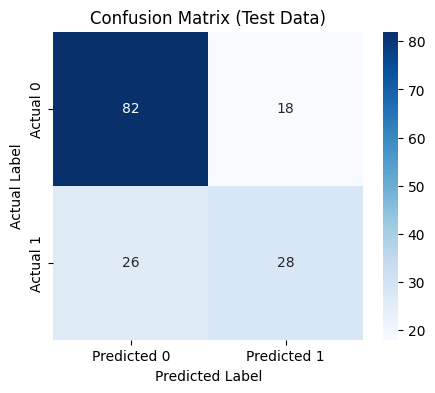

In [41]:

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Test Data)")
plt.show()

**9. ROC Curve + AUC**

ROC AUC Score: 0.823


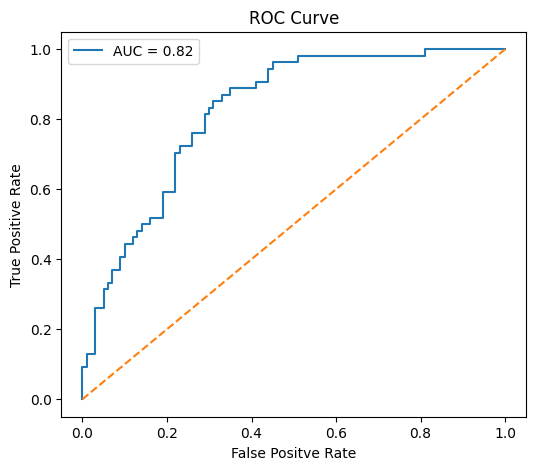

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

print(f"ROC AUC Score: {auc_score:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0, 1], linestyle="--")
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Final Notes / Summary**

In this notebook, we demonstrated the complete **classification workflow** on the Pima Indians Diabetes dataset:

- Loaded the dataset and separated **features (X)** and **target (y)**.
- Split the data into **training** and **test** sets using `train_test_split` (with `stratify=y` to preserve class balance).
- Scaled the features using **StandardScaler** (fit only on training data, then applied to test data).
- Trained a **Logistic Regression** classifier.
- Evaluated the model using:
  - **Accuracy, Precision, Recall, F1-score**
  - **Confusion Matrix** (shown as a heatmap for easy interpretation)
  - **ROC Curve and ROC-AUC** using predicted probabilities

Note: This was a **training + evaluation demo**. Deeper EDA, handling zero-as-missing values, feature engineering, and threshold tuning can be explored later.